In [1]:
import os
import pandas as pd
import plotnine as pln

# create fasta files from metadata

In [2]:
# base_dir = '../data/ProteinGym_metadata/multiples'
# for file in os.listdir(base_dir):
#     df = pd.read_csv(os.path.join(base_dir, file))
#     file_name = file.strip('.csv')

#     with open(f"../data/ProteinGym_fasta/multiples/{file_name}.fasta", "w") as f:
#         for _, row in df.iterrows():
#             f.write(f">{row['mutant']}\n{row['mutated_sequence']}\n")


In [ ]:
# base_dir = '../data/ProteinGym_metadata/singles'
# for file in os.listdir(base_dir):
#     df = pd.read_csv(os.path.join(base_dir, file))
#     file_name = file.strip('.csv')

#     with open(f"../data/ProteinGym_fasta/singles/{file_name}.fasta", "w") as f:
#         for _, row in df.iterrows():
#             f.write(f">{row['mutant']}\n{row['mutated_sequence']}\n")

# count mutations in dataset

In [ ]:
base_dir = '../data/ProteinGym_metadata/doubles/'
for file in os.listdir(base_dir):
    df = pd.read_csv(os.path.join(base_dir, file))
    df['#mutations'] = [len(x.split(':')) for x in df['mutant']]
    df.rename(columns={'mutant':'ID', 'DMS_score':'target'}, inplace=True)
    df.to_csv(os.path.join(base_dir, file), index=False)

df

## 

In [57]:
base_dir = '../data/ProteinGym_metadata/doubles/'
for file in os.listdir(base_dir):
    df = pd.read_csv(os.path.join(base_dir, file))
    if file.strip('.csv') in l:
        print(f'File name: {file}')
        print(df['#mutations'].value_counts())
    

File name: RAD_ANTMA_Tsuboyama_2023_2CJJ.csv
#mutations
1    774
2    138
Name: count, dtype: int64
File name: PSAE_PICP2_Tsuboyama_2023_1PSE.csv
#mutations
1    1219
2     360
Name: count, dtype: int64
File name: THO1_YEAST_Tsuboyama_2023_2WQG.csv
#mutations
1    656
2    623
Name: count, dtype: int64
File name: RPC1_BP434_Tsuboyama_2023_1R69.csv
#mutations
1    1124
2     335
Name: count, dtype: int64
File name: TNKS2_HUMAN_Tsuboyama_2023_5JRT.csv
#mutations
1    1118
2     361
Name: count, dtype: int64


In [ ]:
records = []
base_dir = '../data/ProteinGym_metadata/doubles/'
for file in os.listdir(base_dir):
    name = file.strip('.csv')
    name = name.replace('_', ' ')
    df = pd.read_csv(os.path.join(base_dir, file))
    counts = df['#mutations'].value_counts()
    n_single = counts.get(1, 0)
    n_multiple = counts.drop(1, errors='ignore').sum()
    records.append({'Dataset': name, '#Single': n_single, '#Multiple': n_multiple})

summary_df = pd.DataFrame(records).sort_values('Dataset').reset_index(drop=True)
#summary_df.to_excel('../data/proteinGym_single_to_doubles_metadata.xlsx')
summary_df

,Dataset,#Single,#Multiple
0,A4 HUMAN Seuma 2022,796,14015
1,AMFR HUMAN Tsuboyama 2023 4G3O,820,2152
2,BBC1 YEAST Tsuboyama 2023 1TG0,1084,985
3,BCHB CHLTE Tsuboyama 2023 2KRU,890,682
4,CATR CHLRE Tsuboyama 2023 2AMI,1340,563
5,CBPA2 HUMAN Tsuboyama 2023 1O6X,1357,711
6,CBX4 HUMAN Tsuboyama 2023 2K28,917,1365
7,CSN4 MOUSE Tsuboyama 2023 1UFM,1353,1942
8,CUE1 YEAST Tsuboyama 2023 2MYX,955,625
9,DLG4 HUMAN Faure 2021,1280,5696


# Spliting data into singles and doubles (train/test)

In [3]:
def split_data(df):
    """
    This function splits a dataframe based on number of mutations into train and validation data.
    """
    # Split dataframe
    train_df = df[df["#mutations"]==1]
    val_df = df[df["#mutations"]>1]
   
    return train_df, val_df

In [60]:
base_dir = '../data/ProteinGym_metadata/doubles/'
for file in os.listdir(base_dir):
    df = pd.read_csv(os.path.join(base_dir, file))
   
    train, val = split_data(df)
    print(file)

    print(f"Train shape: {train.shape}")
    print(f"Val shape: {val.shape}")
    break
   

BBC1_YEAST_Tsuboyama_2023_1TG0.csv
Train shape: (1084, 5)
Val shape: (985, 5)


# Aditive model

In [3]:
import os
import re
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.metrics import r2_score
from collections import defaultdict

class PositionAwareAdditiveModel:
    def __init__(self, mutation_col='mutation', score_col='score'):
        self.mutation_col = mutation_col
        self.score_col = score_col
        
        # Fallback storage layers
        self.single_mutant_map = {}
        self.position_avg_map = {}
        self.global_median = 0.0
        
    def _extract_position(self, mut_string):
        """Extracts the numeric position from a mutation string (e.g., 'M2D' -> '2')."""
        match = re.search(r'\d+', mut_string)
        return match.group(0) if match else None

    def data_split(self, df):
        """
        Splits the mixed dataset into singles (Train) and doubles (Test),
        and extracts multi-layer baseline metrics from the singles.
        """
    
        is_double = df[self.mutation_col].str.contains(':', na=False)
        train_df = df[~is_double].copy()
        test_df = df[is_double].copy()
        
        # Layer 1: Specific Mutation Lookup Map
        self.single_mutant_map = dict(zip(train_df[self.mutation_col], train_df[self.score_col]))
        
        # Layer 2: Position-Specific Average Map
        position_scores = defaultdict(list)
        for mut, score in self.single_mutant_map.items():
            pos = self._extract_position(mut)
            if pos:
                position_scores[pos].append(score)
        self.position_avg_map = {pos: np.mean(scores) for pos, scores in position_scores.items()}

        # Layer 3: Global Protein Median (Absolute fallback)
        if self.single_mutant_map:
            self.global_median = np.median(list(self.single_mutant_map.values()))
        else:
            self.global_median = 0.0
        
        return train_df, test_df

    def _get_single_score_with_fallback(self, mut):
        """Hierarchical lookup sequence: Exact Mutant -> Position Average -> Global Median"""
        # 1. Try exact match (e.g., M2D)
        if mut in self.single_mutant_map:
            return self.single_mutant_map[mut]
            
        # 2. Try position-based match (e.g., Position 2 average)
        pos = self._extract_position(mut)
        if pos in self.position_avg_map:
            return self.position_avg_map[pos]
        
        # 3. Final fallback: global median
        return self.global_median

    def predict(self, test_df):
        """
        Predicts double mutant scores by summing their constituent single mutant scores,
        utilizing position-based substitution to guarantee a prediction for every row.
        """
        predictions = []
        
        for mut_string in test_df[self.mutation_col]:
            parts = mut_string.split(':')
            
            if len(parts) == 2:
                mut1, mut2 = parts[0], parts[1]
                
                # Extract scores using the fallback hierarchy
                score1 = self._get_single_score_with_fallback(mut1)
                score2 = self._get_single_score_with_fallback(mut2)
                
                # Compute additive expectation
                predictions.append(score1 + score2)
                    
                
        return np.array(predictions)
    
    def evaluate(self, test_df, y_pred):
        """
        Evaluates the predictions across the complete, unbroken test array.
        """
        eval_df = test_df.copy()
        eval_df['predicted_score'] = y_pred
        
        y_true = eval_df[self.score_col].values
        y_pred_all = eval_df['predicted_score'].values
        
        # Standard regression metrics over the full matrix
        r2 = r2_score(y_true, y_pred_all)
        rho, _ = spearmanr(y_true, y_pred_all)
        mae = np.mean(np.abs(y_true - y_pred_all))

        res_dict = {
            "Dataset": None,
            "R2_score_test": r2,
            "MAE_score_test": mae,
            "rho_score_test": rho,
            }
        
        results = pd.DataFrame.from_dict(res_dict, orient='index').T.reset_index(drop=True)
        
        return eval_df, results

In [47]:
base_dir = '../data/ProteinGym_metadata/doubles/'

cols = ['Dataset', 'R2_score_test', 'rho_score_test']

model = PositionAwareAdditiveModel(mutation_col='ID', score_col='target')

res1 = pd.DataFrame()
for file in os.listdir(base_dir):
    df = pd.read_csv(os.path.join(base_dir, file))
    train_singles, test_doubles = model.data_split(df)
    y_pred = model.predict(test_doubles)
    val_df, res_df = model.evaluate(test_doubles, y_pred)

    res_df['Dataset'] = file.strip('.csv')
    res1 = pd.concat([res1, res_df]).reset_index(drop=True)

res1 = res1[cols] 
res1['Model'] = 'Additive'
res1.rename(columns={'R2_score_test':'R2', 'rho_score_test':'Rho'}, inplace=True)
res1.head()

,Dataset,R2,Rho,Model
0,BBC1_YEAST_Tsuboyama_2023_1TG0,-0.411242,0.620374,Additive
1,RAD_ANTMA_Tsuboyama_2023_2CJJ,-3.373870,0.313491,Additive
2,VILI_CHICK_Tsuboyama_2023_1YU5,-0.505888,0.694746,Additive
3,AMFR_HUMAN_Tsuboyama_2023_4G3O,-4.799327,0.639884,Additive
4,SDA_BACSU_Tsuboyama_2023_1PV0,-2.815252,0.684185,Additive


# load lassoCV results on sigles to doubles split

In [71]:
res2 = pd.DataFrame()
base_dir = '../experiments/doubles/esm2_650m/mut_split'

for file in os.listdir(base_dir):
    res_df = pd.read_csv(os.path.join(base_dir, file)).drop('Unnamed: 0', axis=1)

    res_df['Dataset'] = file.strip('.csv')
    res2 = pd.concat([res2, res_df]).reset_index(drop=True)

res2 = res2[cols] 
res2['Split'] = 'Single-to-double' 
res2['Model'] = 'ESM-2 650M' 
res2.rename(columns={'R2_score_test':'R2', 'rho_score_test':'Rho'}, inplace=True)

res2.head()

,Dataset,R2,Rho,Split,Model
0,RD23A_HUMAN_Tsuboyama_2023_1IFY,0.587239,0.789169,Single-to-double,ESM-2 650M
1,SPTN1_CHICK_Tsuboyama_2023_1TUD,0.247770,0.735797,Single-to-double,ESM-2 650M
2,ODP2_GEOSE_Tsuboyama_2023_1W4G,0.495215,0.620284,Single-to-double,ESM-2 650M
3,HECD1_HUMAN_Tsuboyama_2023_3DKM,-0.244082,0.475586,Single-to-double,ESM-2 650M
4,SR43C_ARATH_Tsuboyama_2023_2N88,-0.182614,0.862223,Single-to-double,ESM-2 650M


In [49]:
res12 = res1.merge(res2, on='Dataset', suffixes=('_Additive', '_esm2_650m'))
res12.head()

,Dataset,R2_Additive,Rho_Additive,Model_Additive,R2_esm2_650m,Rho_esm2_650m,Model_esm2_650m
0,BBC1_YEAST_Tsuboyama_2023_1TG0,-0.411242,0.620374,Additive,0.050238,0.606863,Single-to-double
1,RAD_ANTMA_Tsuboyama_2023_2CJJ,-3.373870,0.313491,Additive,-9.228797,0.321494,Single-to-double
2,VILI_CHICK_Tsuboyama_2023_1YU5,-0.505888,0.694746,Additive,0.034673,0.630453,Single-to-double
3,AMFR_HUMAN_Tsuboyama_2023_4G3O,-4.799327,0.639884,Additive,-0.653195,0.223136,Single-to-double
4,SDA_BACSU_Tsuboyama_2023_1PV0,-2.815252,0.684185,Additive,-0.988251,0.706496,Single-to-double


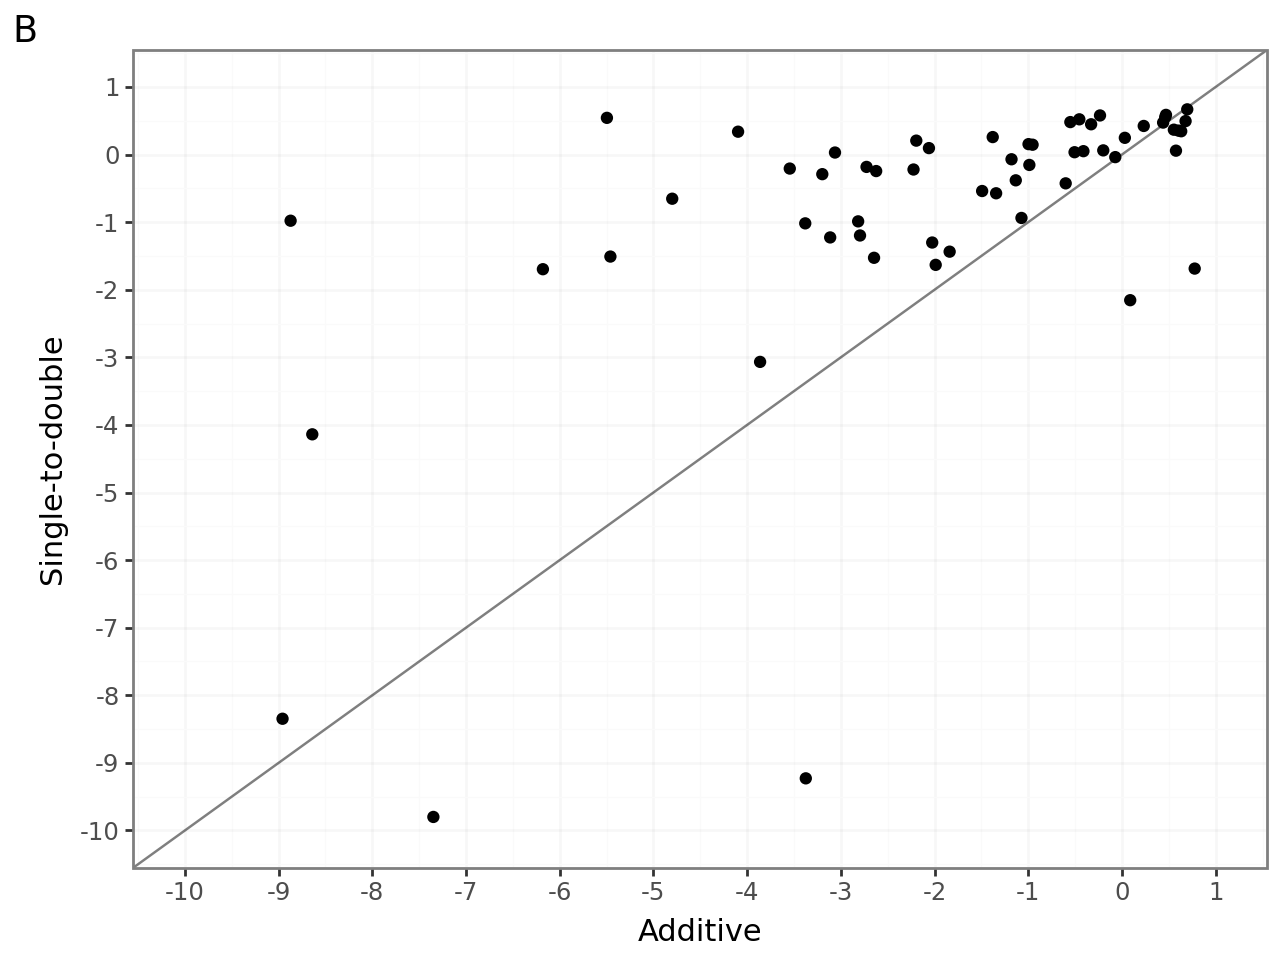

In [50]:
brs = [1, 0, -1, -2, -3, -4, -5, -6, -7, -8, -9, -10]
lbs = ['1', '0', '1', '', '', '4', '', '', '7', '', '', '10']

p2 = (
    pln.ggplot(res12, pln.aes(x='R2_Additive', y='R2_esm2_650m'))
    + pln.geom_point()
    + pln.geom_abline(alpha=0.5)
    + pln.labs(
        x= 'Additive',
        y= 'Single-to-double',
        tag='B'
    )
    + pln.theme_bw()
    + pln.theme(
        legend_position='top',
        panel_grid_major=pln.element_line(color='black', alpha=0.03)
        )
    + pln.scale_y_continuous(breaks=brs, limits=(1, -10))
    + pln.scale_x_continuous(breaks=brs, limits=(1, -10))
)
p2

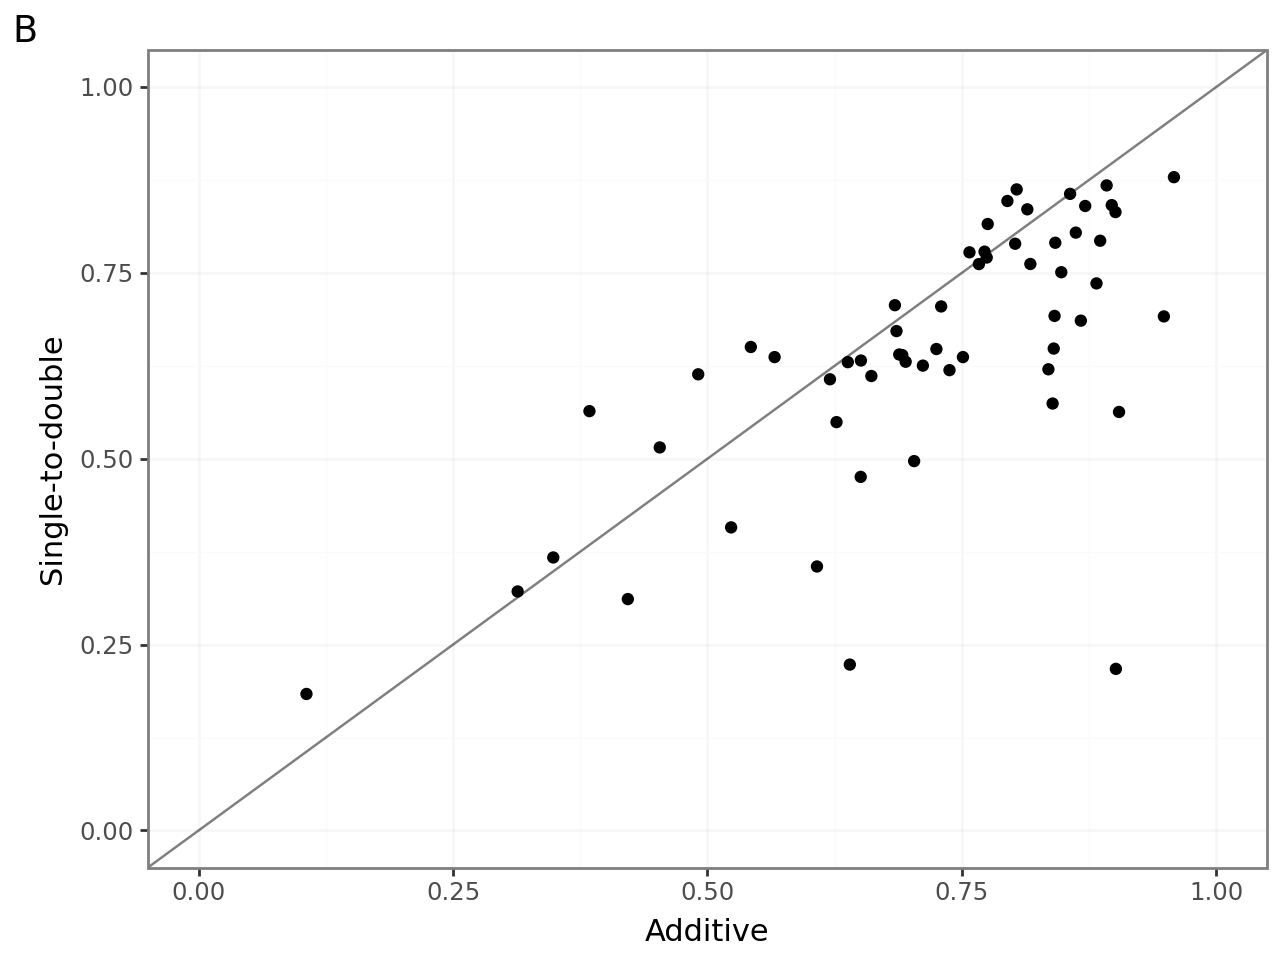

In [51]:
p22 = (
    pln.ggplot(res12, pln.aes(x='Rho_Additive', y='Rho_esm2_650m'))
    + pln.geom_point()
    + pln.geom_abline(alpha=0.5)
    + pln.labs(
        x= 'Additive',
        y= 'Single-to-double',
        tag='B'
    )
    + pln.theme_bw()
    + pln.theme(
        legend_position='top',
        panel_grid_major=pln.element_line(color='black', alpha=0.03)
        )
    + pln.ylim(0, 1)
    + pln.xlim(0, 1)
)
p22

# load lassoCV results on pooled split

In [72]:
res3 = pd.DataFrame()
base_dir = '../experiments/doubles/esm2_650m/pooled'

for file in os.listdir(base_dir):
    res_df = pd.read_csv(os.path.join(base_dir, file)).drop('Unnamed: 0', axis=1)

    res_df['Dataset'] = file.strip('.csv')
    res3 = pd.concat([res3, res_df]).reset_index(drop=True)

res3 = res3.groupby('Dataset', as_index=False).mean() 
res3 = res3[cols] 
res3['Model'] = 'ESM-2 650M' 
res3['Split'] = 'Pooled' 
res3.rename(columns={'R2_score_test':'R2', 'rho_score_test':'Rho'}, inplace=True)
res3.head()

,Dataset,R2,Rho,Model,Split
0,A4_HUMAN_Seuma_2022,0.740569,0.874380,ESM-2 650M,Pooled
1,AMFR_HUMAN_Tsuboyama_2023_4G3O,0.849947,0.922577,ESM-2 650M,Pooled
2,BBC1_YEAST_Tsuboyama_2023_1TG0,0.821598,0.911944,ESM-2 650M,Pooled
3,BCHB_CHLTE_Tsuboyama_2023_2KRU,0.845168,0.926644,ESM-2 650M,Pooled
4,CATR_CHLRE_Tsuboyama_2023_2AMI,0.877959,0.927147,ESM-2 650M,Pooled


## merge results

In [73]:
res123 = pd.concat([res1, res2, res3])
#res123.to_csv('../experiments/doubles/esm2_650m/pooled_SingleDoubleSplit_Additive_res.csv')
#res123 = pd.read_csv('../experiments/doubles/esm2_650m/pooled_SingleDoubleSplit_Additive_res.csv')

In [74]:
res123['Model'] = pd.Categorical(res123['Model'], categories=['Pooled', 'Single-to-double', 'Additive'])

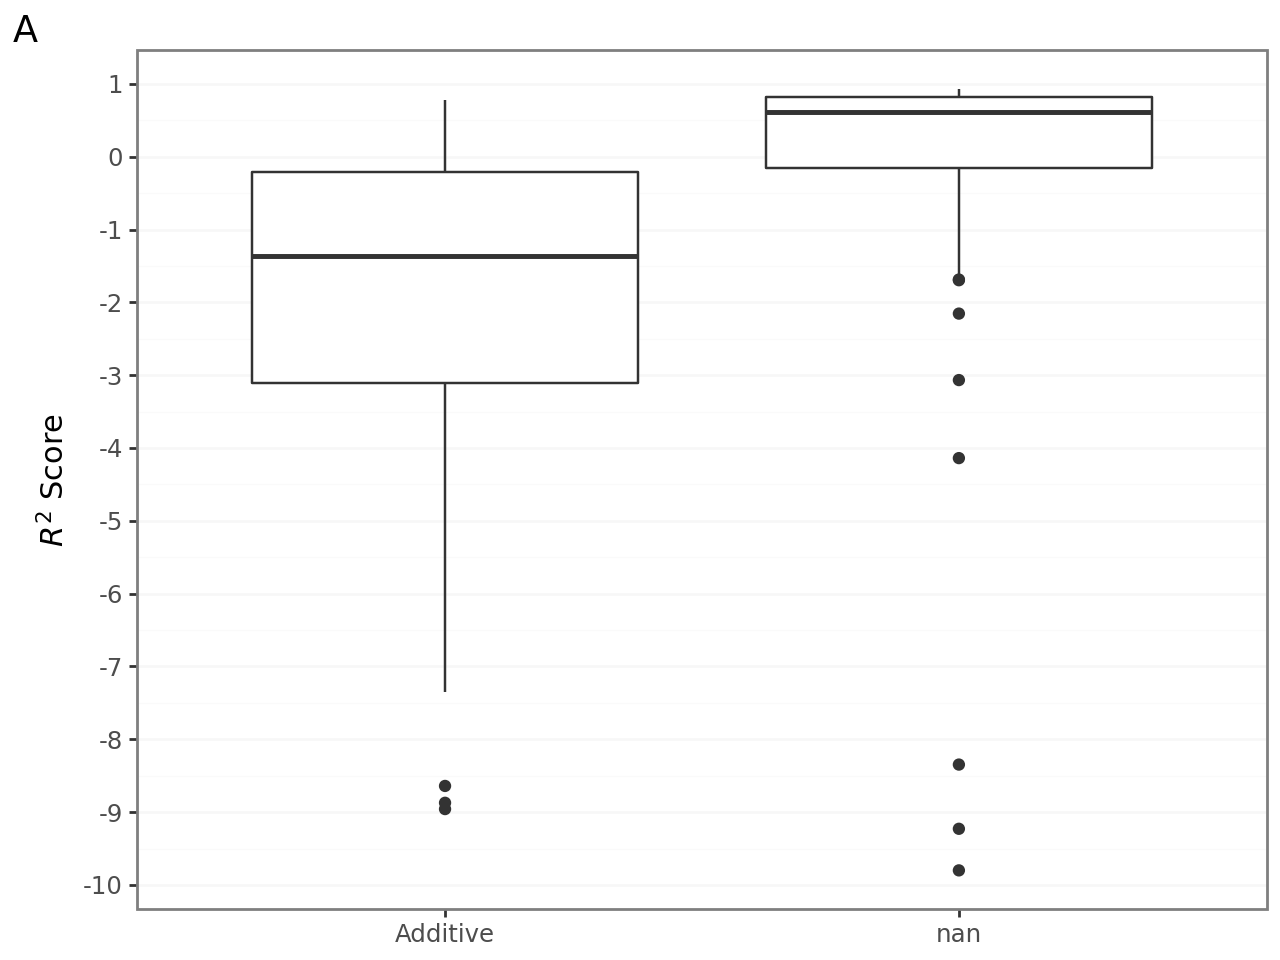

In [75]:
p1 = (
    pln.ggplot(res123, pln.aes(x='Model', y='R2'))
    + pln.geom_boxplot()
    + pln.labs(
        x='',
        y="$R^2$ Score",
        tag='A' 
    )
    + pln.scale_y_continuous(breaks=brs)
    + pln.theme_bw()
    + pln.theme(
        panel_grid_major_x=pln.element_blank(),
        panel_grid_major=pln.element_line(color='black', alpha=0.03)
                )
   
)
p1

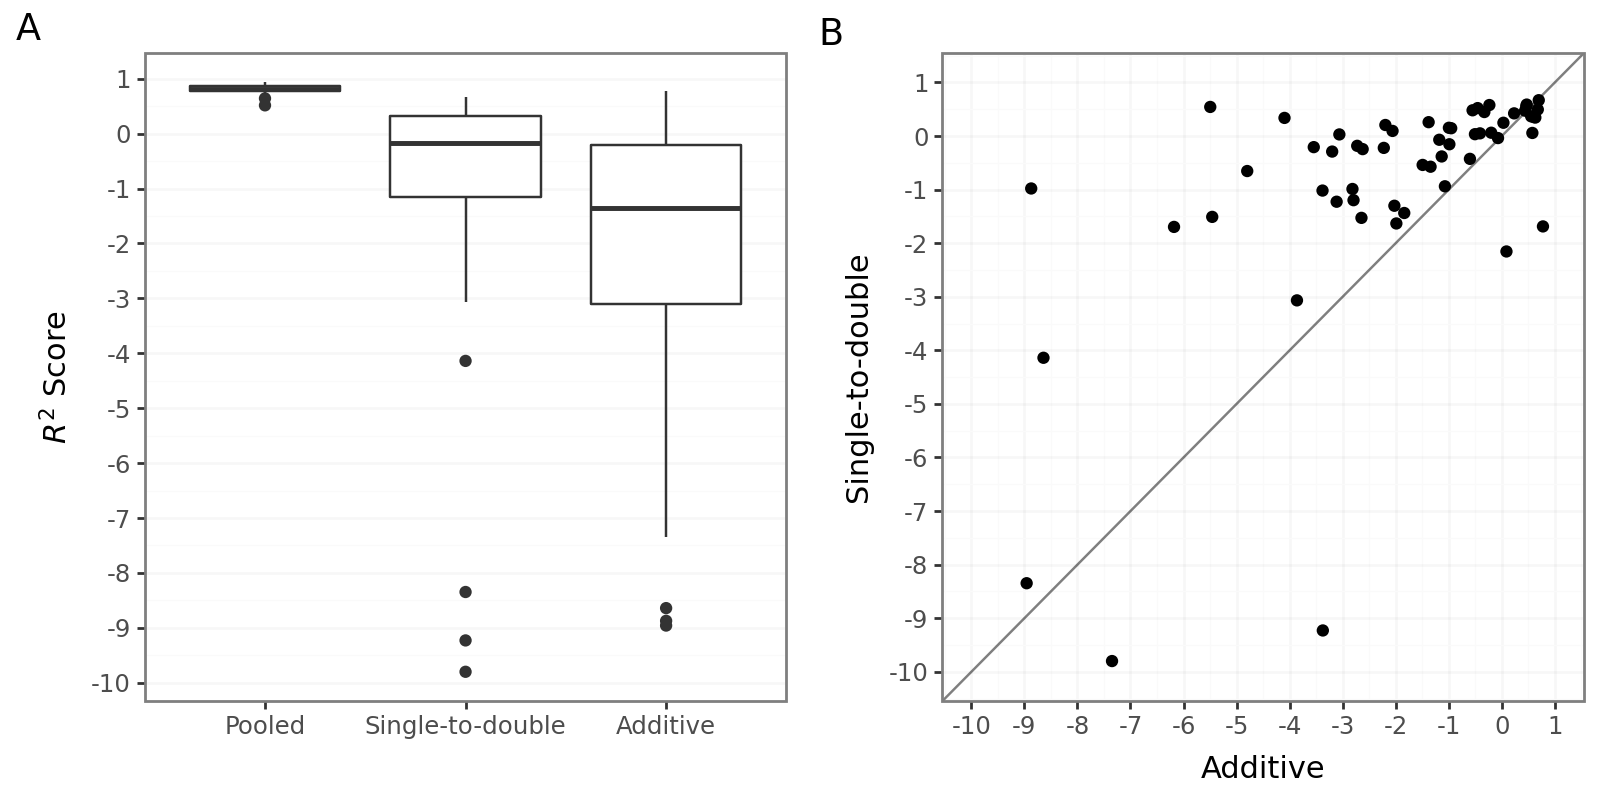

In [59]:
comp = (p1 | p2)
plot = comp + pln.theme(figure_size=(8, 4))
#plot.save(filename='../experiments/figures/pooled_SingleDouble_Additive_esm2_650m.png', dpi=600)
plot

# ESM C 600M

In [76]:
res2_esmc = pd.DataFrame()
base_dir = '../experiments/doubles/esmc_600m/mut_split'

for file in os.listdir(base_dir):
    res_df = pd.read_csv(os.path.join(base_dir, file)).drop('Unnamed: 0', axis=1)

    res_df['Dataset'] = file.strip('.csv')
    res2_esmc = pd.concat([res2_esmc, res_df]).reset_index(drop=True)

res2_esmc = res2_esmc[cols] 
res2_esmc['Split'] = 'Single-to-double' 
res2_esmc['Model'] = 'ESM C 600M' 
res2_esmc.rename(columns={'R2_score_test':'R2', 'rho_score_test':'Rho'}, inplace=True)
res2_esmc.head()

,Dataset,R2,Rho,Split,Model
0,CATR_CHLRE_Tsuboyama_2023_2AMI,0.703810,0.840313,Single-to-double,ESM C 600M
1,UBR5_HUMAN_Tsuboyama_2023_1I2T,0.467143,0.739924,Single-to-double,ESM C 600M
2,ODP2_GEOSE_Tsuboyama_2023_1W4G,0.680559,0.694273,Single-to-double,ESM C 600M
3,SPG1_STRSG_Olson_2014,0.712586,0.884027,Single-to-double,ESM C 600M
4,RPC1_BP434_Tsuboyama_2023_1R69,0.482716,0.791146,Single-to-double,ESM C 600M


In [77]:
res3_esmc = pd.DataFrame()
base_dir = '../experiments/doubles/esmc_600m/pooled'

for file in os.listdir(base_dir):
    res_df = pd.read_csv(os.path.join(base_dir, file)).drop('Unnamed: 0', axis=1)

    res_df['Dataset'] = file.strip('.csv')
    res3_esmc = pd.concat([res3_esmc, res_df]).reset_index(drop=True)

res3_esmc = res3_esmc.groupby('Dataset', as_index=False).mean() 
res3_esmc = res3_esmc[cols] 
res3_esmc['Split'] = 'Pooled' 
res3_esmc['Model'] = 'ESM C 600M' 
res3_esmc.rename(columns={'R2_score_test':'R2', 'rho_score_test':'Rho'}, inplace=True)
res3_esmc.head()

,Dataset,R2,Rho,Split,Model
0,A4_HUMAN_Seuma_2022,0.516959,0.733517,Pooled,ESM C 600M
1,AMFR_HUMAN_Tsuboyama_2023_4G3O,0.823977,0.910423,Pooled,ESM C 600M
2,BBC1_YEAST_Tsuboyama_2023_1TG0,0.830810,0.910988,Pooled,ESM C 600M
3,BCHB_CHLTE_Tsuboyama_2023_2KRU,0.875417,0.941233,Pooled,ESM C 600M
4,CATR_CHLRE_Tsuboyama_2023_2AMI,0.860193,0.915578,Pooled,ESM C 600M


In [78]:
res = pd.concat([res2, res3, res2_esmc, res3_esmc])
res

,Dataset,R2,Rho,Split,Model
0,RD23A_HUMAN_Tsuboyama_2023_1IFY,0.587239,0.789169,Single-to-double,ESM-2 650M
1,SPTN1_CHICK_Tsuboyama_2023_1TUD,0.247770,0.735797,Single-to-double,ESM-2 650M
2,ODP2_GEOSE_Tsuboyama_2023_1W4G,0.495215,0.620284,Single-to-double,ESM-2 650M
3,HECD1_HUMAN_Tsuboyama_2023_3DKM,-0.244082,0.475586,Single-to-double,ESM-2 650M
4,SR43C_ARATH_Tsuboyama_2023_2N88,-0.182614,0.862223,Single-to-double,ESM-2 650M
...,...,...,...,...,...
53,UBR5_HUMAN_Tsuboyama_2023_1I2T,0.864772,0.921156,Pooled,ESM C 600M
54,VILI_CHICK_Tsuboyama_2023_1YU5,0.901521,0.947923,Pooled,ESM C 600M
55,YAIA_ECOLI_Tsuboyama_2023_2KVT,0.817958,0.916491,Pooled,ESM C 600M
56,YAP1_HUMAN_Araya_2012,0.442578,0.728194,Pooled,ESM C 600M


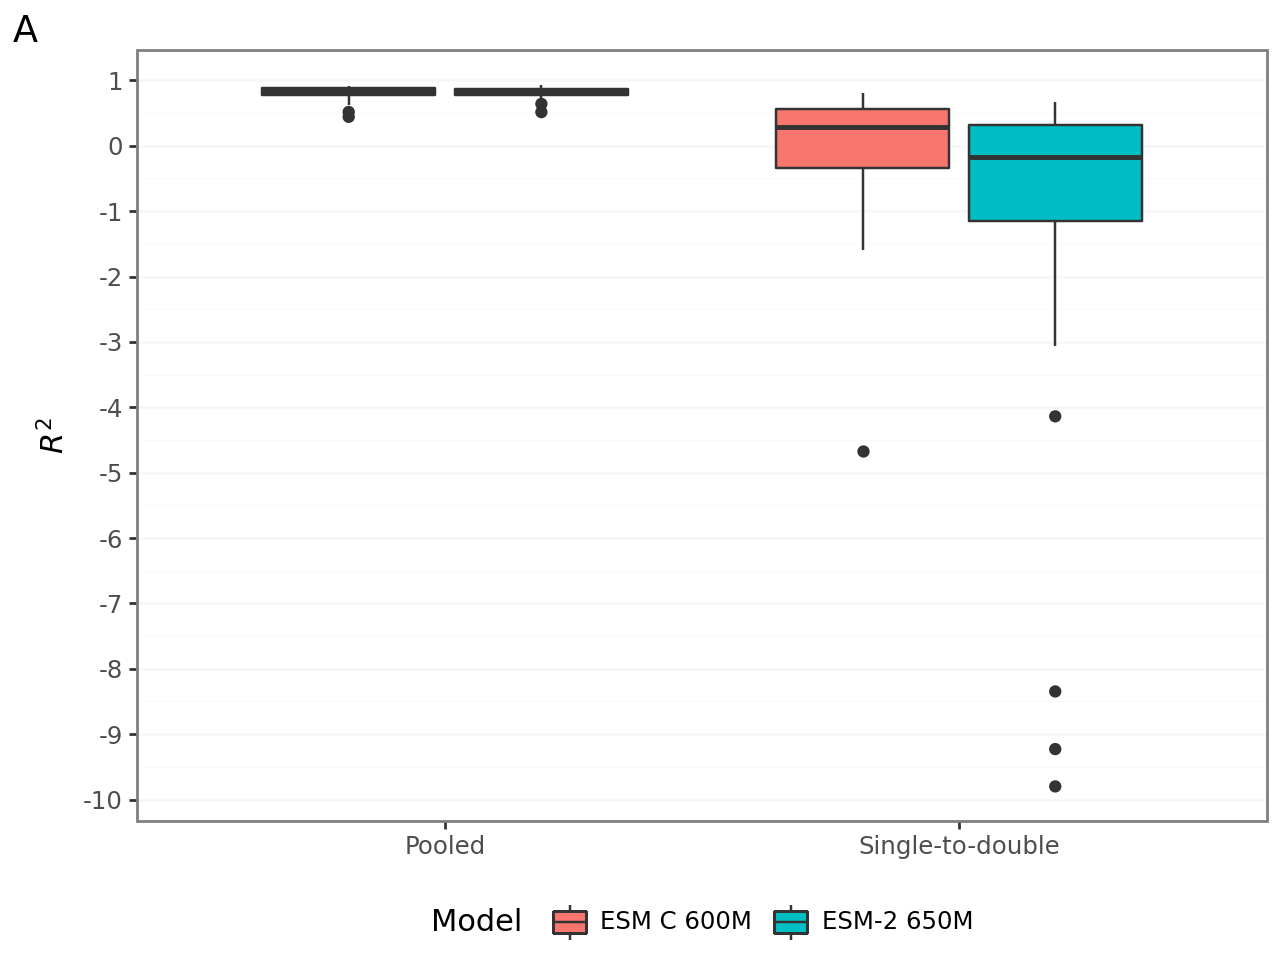

In [116]:
pa = (
    pln.ggplot(res, pln.aes(x='Split', y='R2', fill='Model'))
    + pln.geom_boxplot()
    + pln.labs(
        x='',
        y="$R^2$",
        tag='A' 
    )
    + pln.scale_y_continuous(breaks=brs)
    + pln.theme_bw()
    + pln.theme(
        legend_position='bottom',
        panel_grid_major_x=pln.element_blank(),
        panel_grid_major=pln.element_line(color='black', alpha=0.03)
                )
   
)
pa

/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/scales/scales.py:48: PlotnineWarning: Scale for 'y' is already present.
Adding another scale for 'y',
which will replace the existing scale.



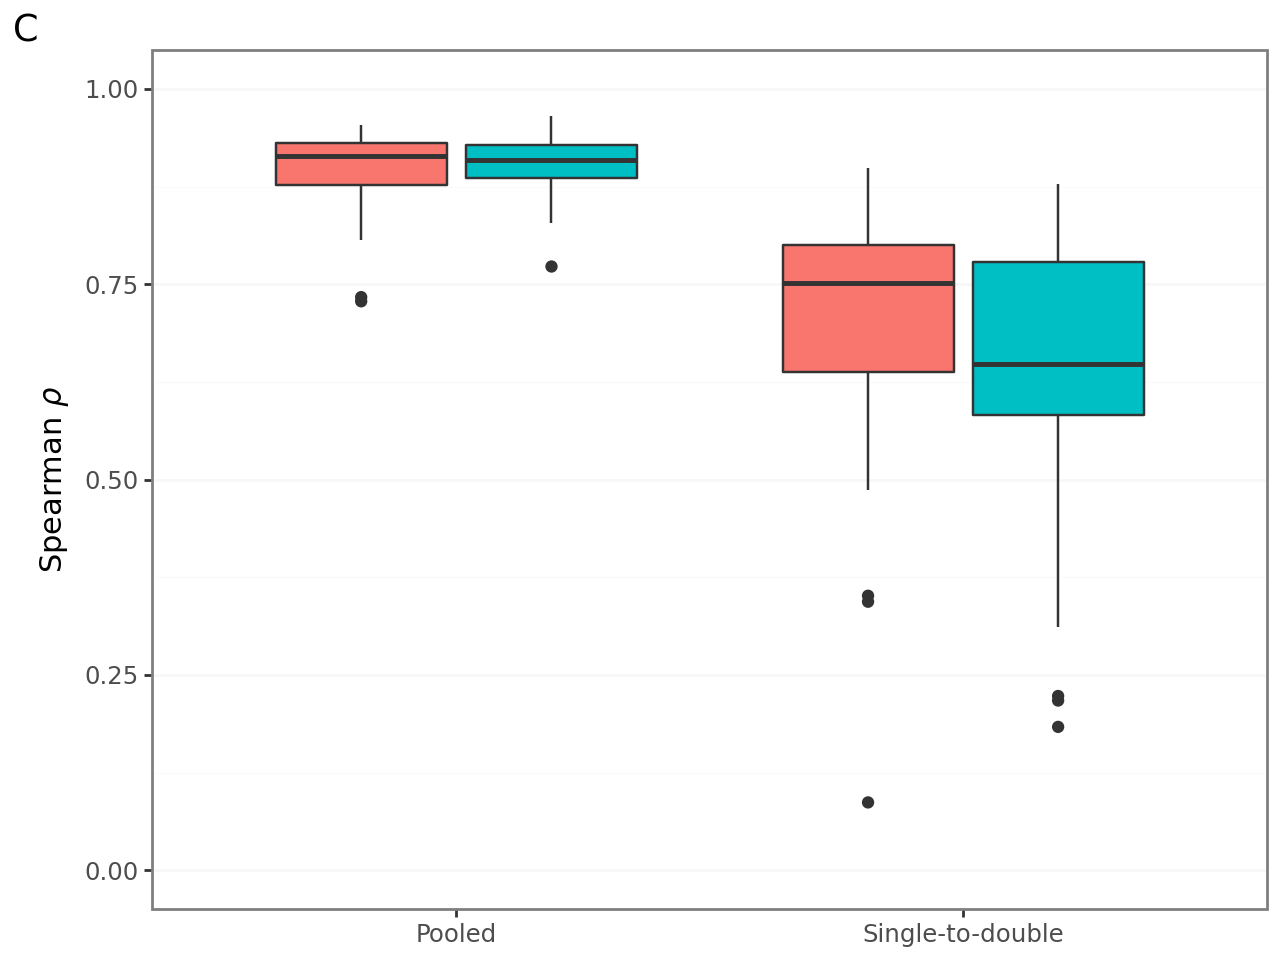

In [118]:
paa = (
    pln.ggplot(res, pln.aes(x='Split', y='Rho', fill='Model'))
    + pln.geom_boxplot()
    + pln.labs(
        x='',
        y=r"Spearman $\rho$",
        tag='C' 
    )
    + pln.scale_y_continuous(breaks=brs)
    + pln.theme_bw()
    + pln.theme(
        legend_position='none',
        panel_grid_major_x=pln.element_blank(),
        panel_grid_major=pln.element_line(color='black', alpha=0.03)
                )
    + pln.ylim(0,1)
   
)
paa

In [95]:
res12_esmc = res1.merge(res2_esmc, on='Dataset', suffixes=('_Additive', '_esmc_600m'))
res12_esmc.head()

,Dataset,R2_Additive,Rho_Additive,Model_Additive,R2_esmc_600m,Rho_esmc_600m,Split,Model_esmc_600m
0,BBC1_YEAST_Tsuboyama_2023_1TG0,-0.411242,0.620374,Additive,0.177996,0.667076,Single-to-double,ESM C 600M
1,RAD_ANTMA_Tsuboyama_2023_2CJJ,-3.373870,0.313491,Additive,-1.315238,0.503883,Single-to-double,ESM C 600M
2,VILI_CHICK_Tsuboyama_2023_1YU5,-0.505888,0.694746,Additive,0.363599,0.629980,Single-to-double,ESM C 600M
3,AMFR_HUMAN_Tsuboyama_2023_4G3O,-4.799327,0.639884,Additive,-1.091273,0.738379,Single-to-double,ESM C 600M
4,SDA_BACSU_Tsuboyama_2023_1PV0,-2.815252,0.684185,Additive,-0.375342,0.743811,Single-to-double,ESM C 600M


In [96]:
brs = [1, 0, -1, -2, -3, -4, -5, -6, -7, -8, -9, -10]
lbs = ['1', '0', '1', '', '', '4', '', '', '7', '', '', '10']

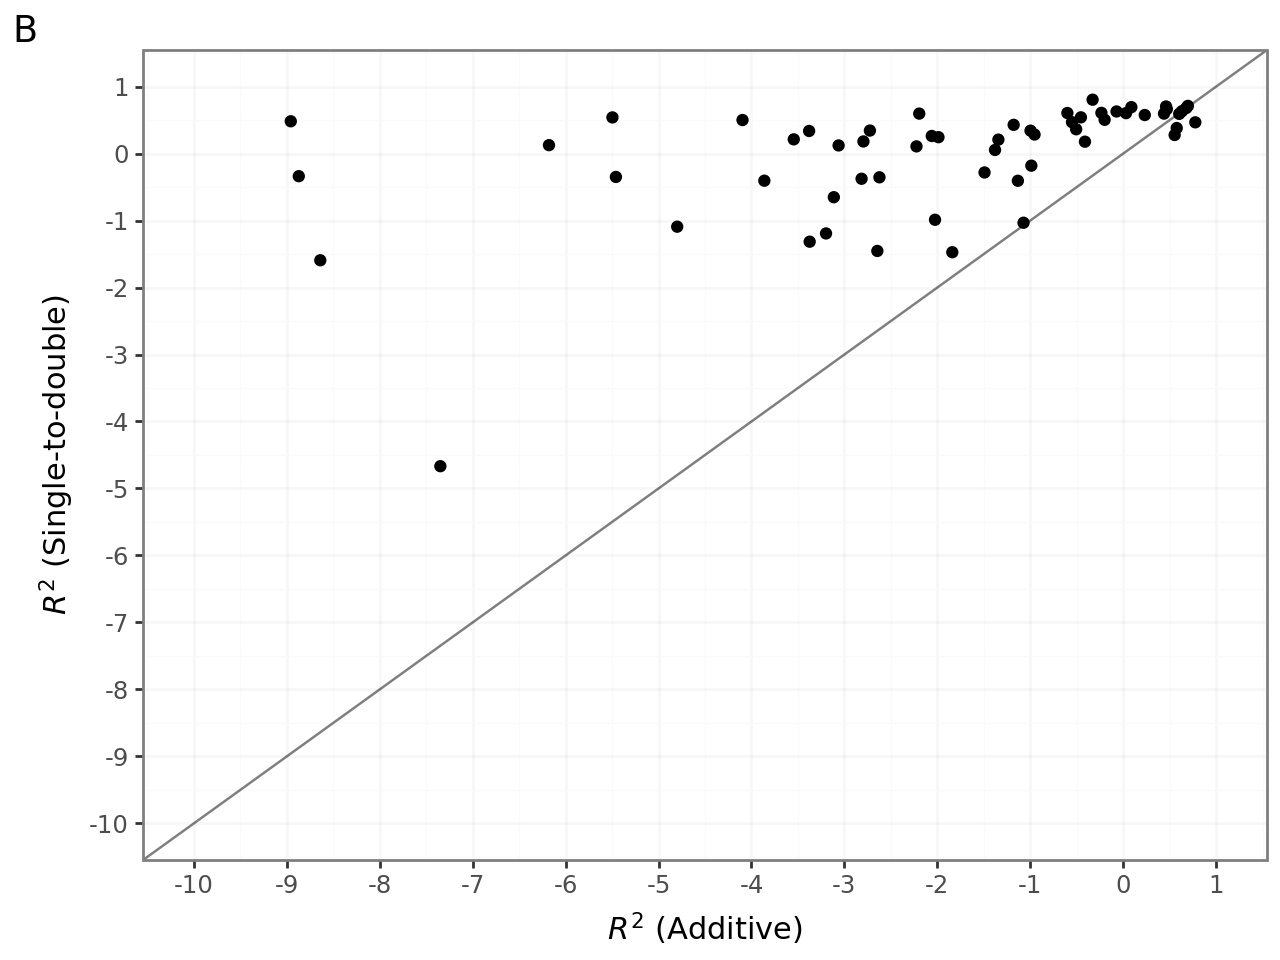

In [110]:
p2b = (
    pln.ggplot(res12_esmc, pln.aes(x='R2_Additive', y='R2_esmc_600m'))
    + pln.geom_point()
    + pln.geom_abline(alpha=0.5)
    + pln.labs(
        #title = 'ESM C',
        x= '$R^2$ (Additive)',
        y= '$R^2$ (Single-to-double)',
        tag='B'
    )
    + pln.theme_bw()
    + pln.theme(
        legend_position='top',
        panel_grid_major=pln.element_line(color='black', alpha=0.03)
        )
    + pln.scale_y_continuous(breaks=brs, limits=(1, -10))
    + pln.scale_x_continuous(breaks=brs, limits=(1, -10))
)
p2b

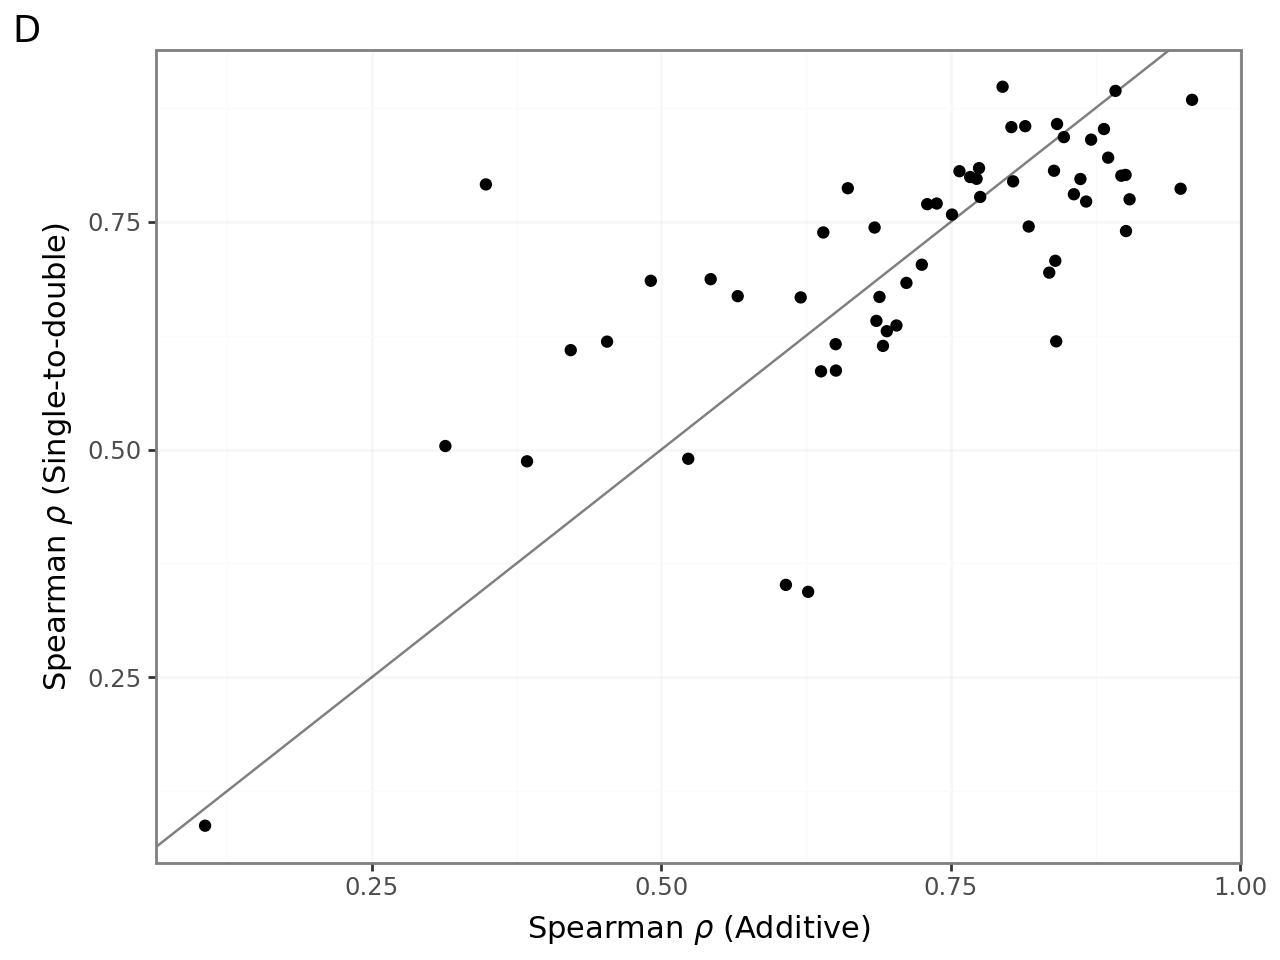

In [109]:
p2bb = (
    pln.ggplot(res12_esmc, pln.aes(x='Rho_Additive', y='Rho_esmc_600m'))
    + pln.geom_point()
    + pln.geom_abline(alpha=0.5)
    + pln.labs(
        #title = 'ESM C',
        x= r'Spearman $\rho$ (Additive)',
        y= r'Spearman $\rho$ (Single-to-double)',
        tag='D'
    )
    + pln.theme_bw()
    + pln.theme(
        legend_position='top',
        panel_grid_major=pln.element_line(color='black', alpha=0.03)
        )
)
p2bb

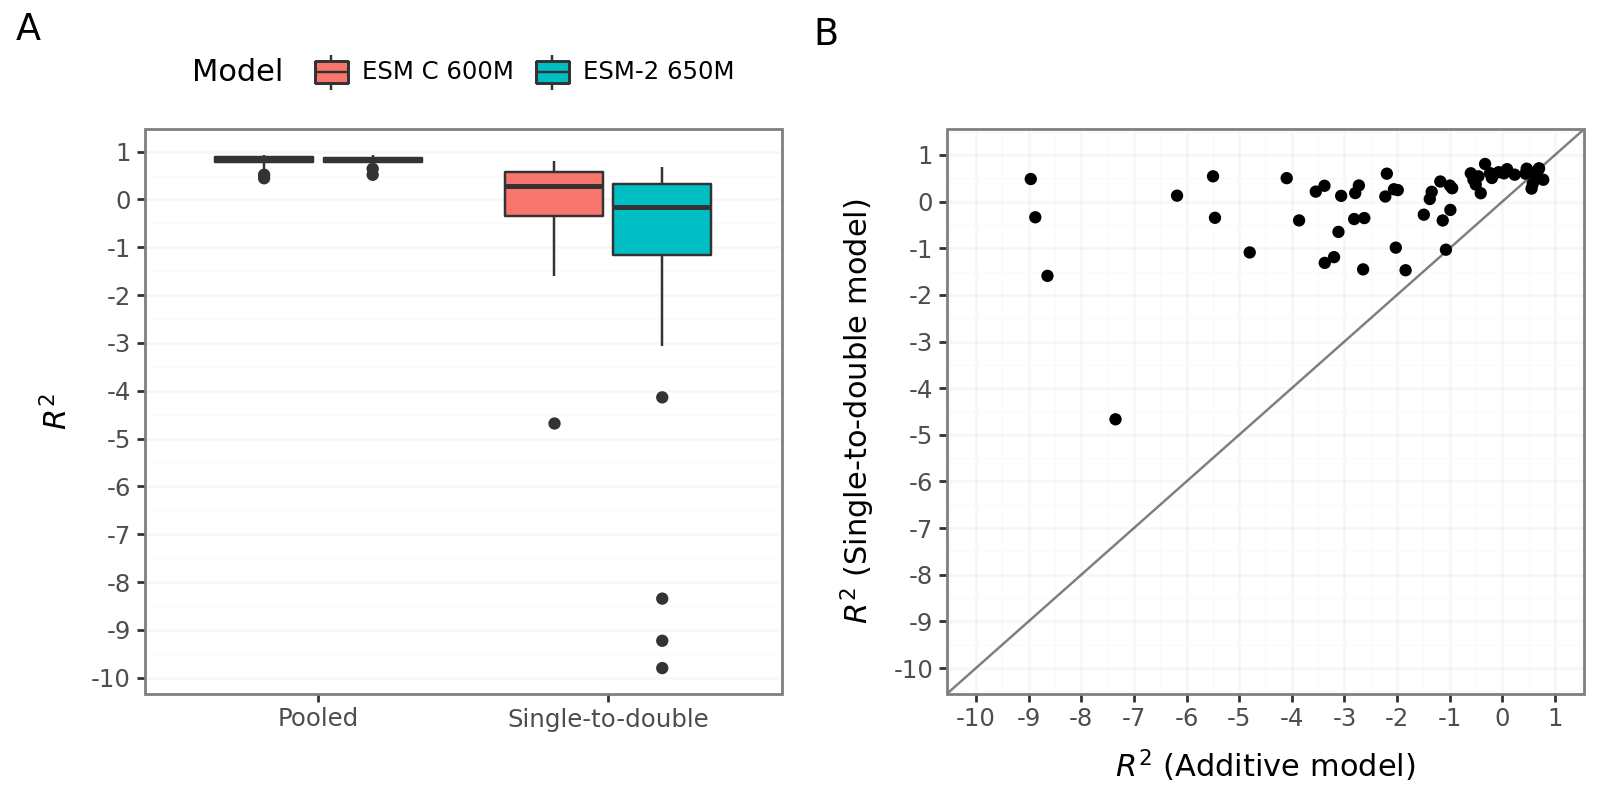

In [101]:
comp = (pa | p2b)
plot = comp + pln.theme(figure_size=(8, 4))
plot.save(filename='../experiments/figures/pooled_SingleDouble_ESMC_Additive_r2.png', dpi=600)
plot

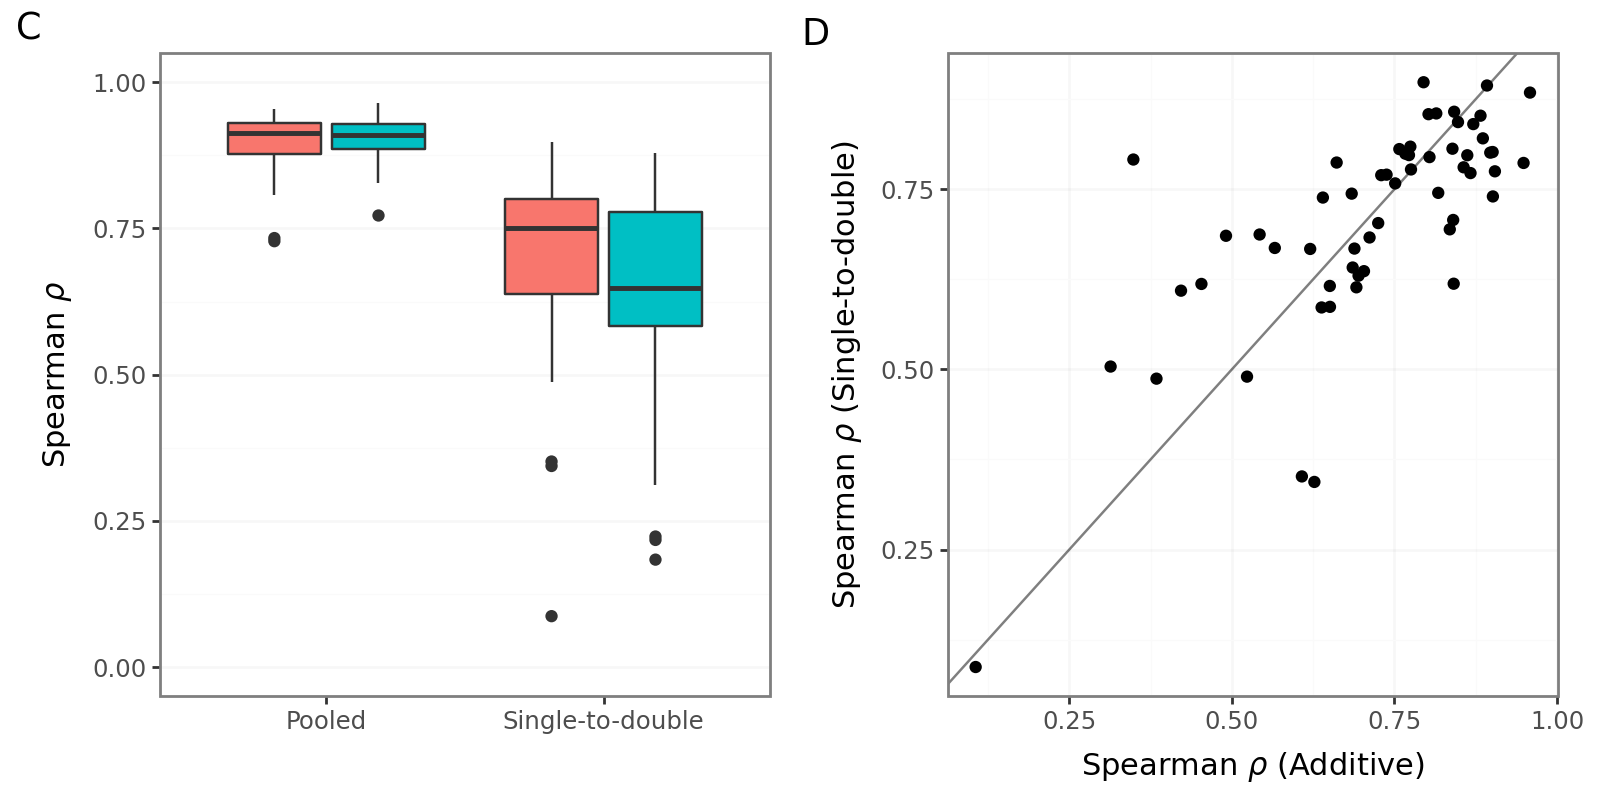

In [ ]:
comp = (paa | p2bb)
plot = comp + pln.theme(figure_size=(8, 4))
#plot.save(filename='../experiments/figures/pooled_SingleDouble_ESMC_Additive_sperman.png', dpi=600)
plot

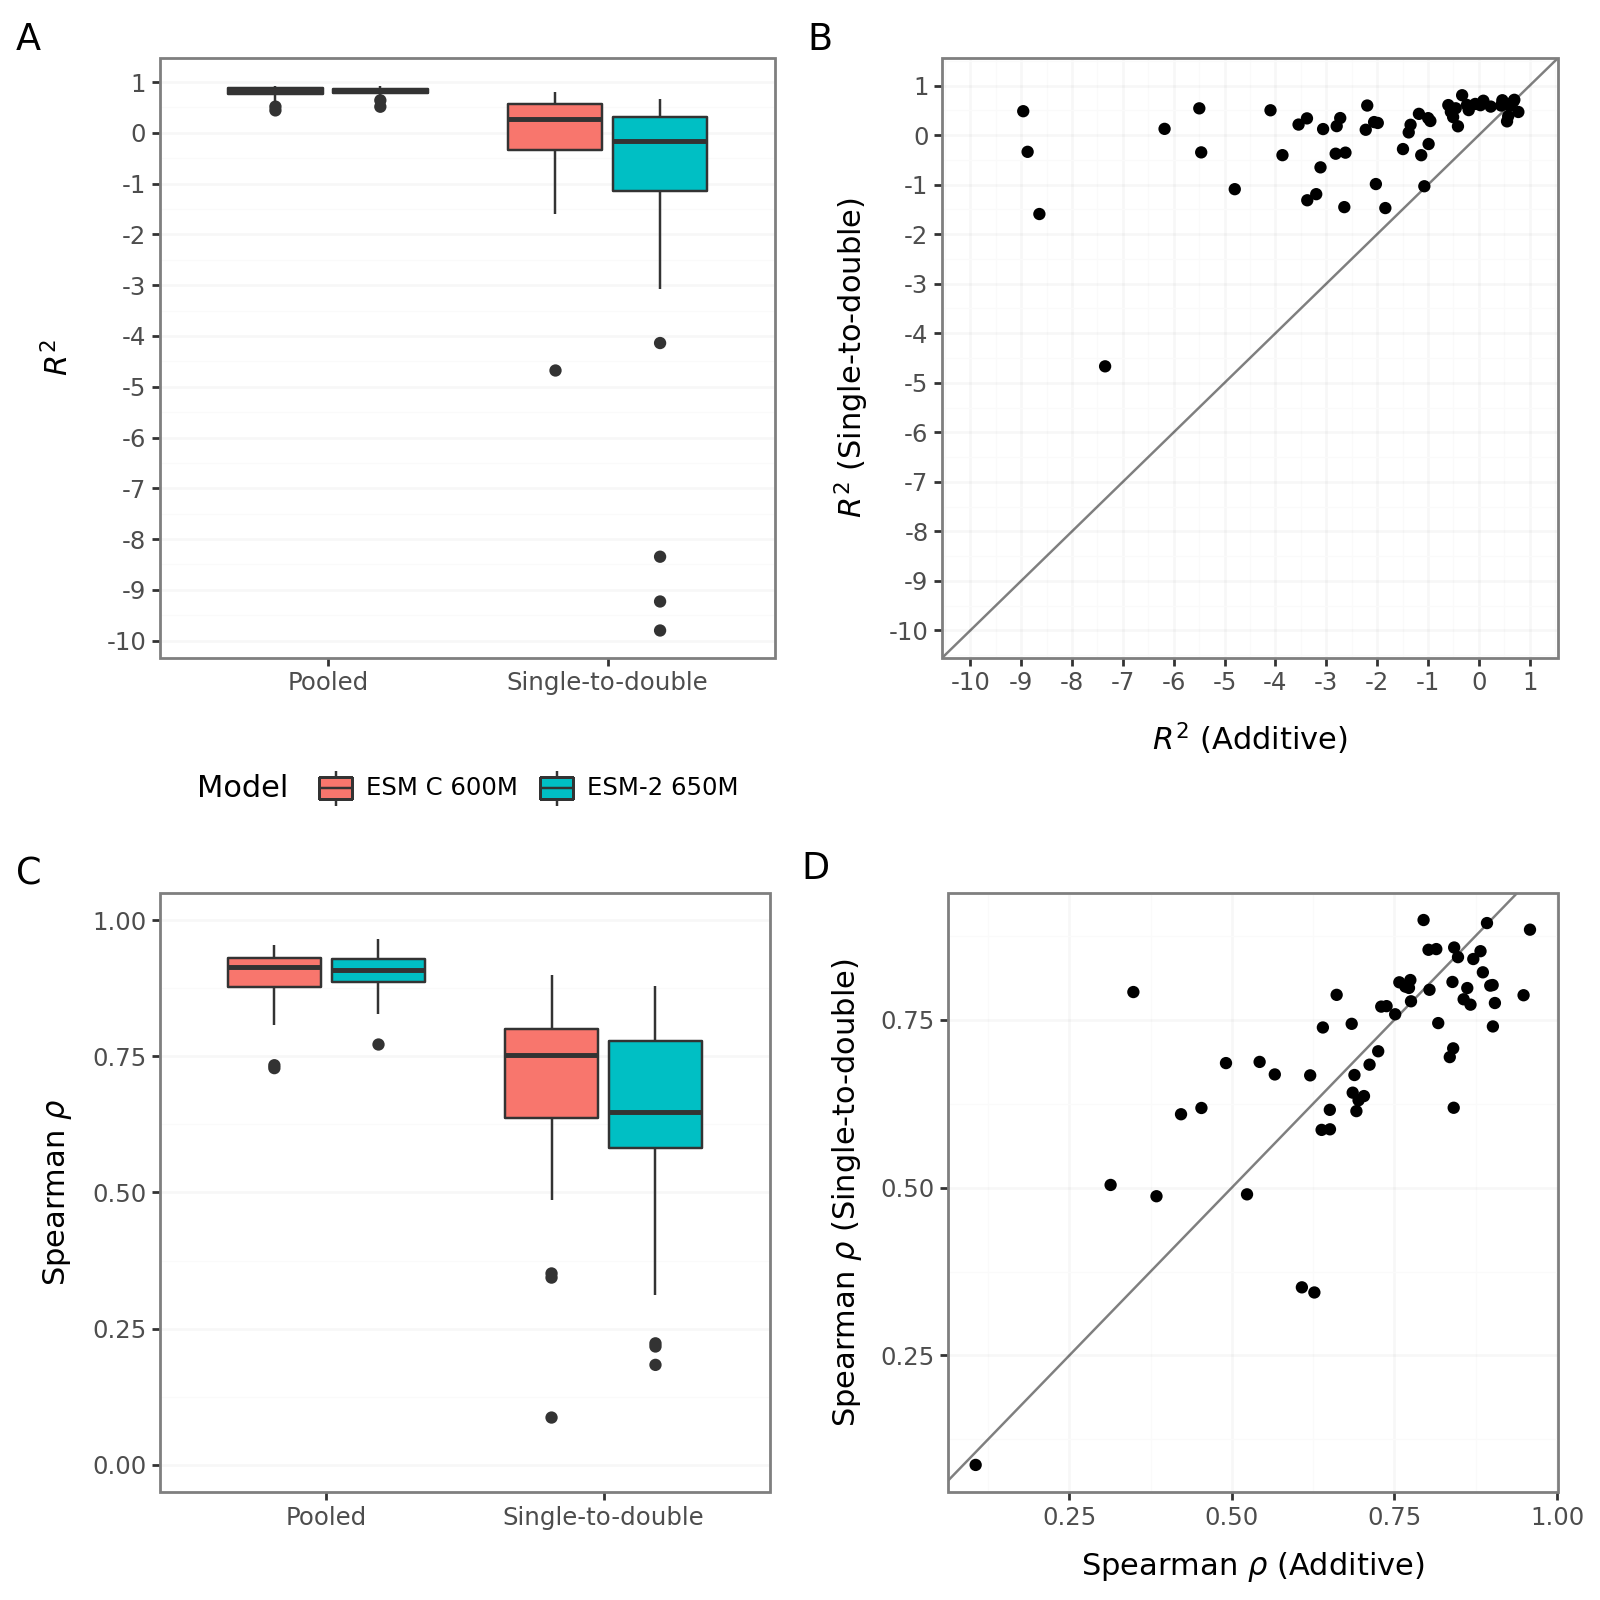

In [120]:
comp = (pa | p2b) / (paa | p2bb)
plot = comp + pln.theme(figure_size=(8, 8))
plot.save(filename='../experiments/figures/pooled_SingleDouble_ESMC_Additive_R2_sperman.png', dpi=600)
plot